In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 0. Cargar Datos

In [6]:
path_ventas = "datos/BD2526_oct_mar_ventasxfacturas(con_zonas).csv"
ventas = pd.read_csv(path_ventas)
ventas.head()

/var/folders/dw/9r647bwd1kl_g5lxtz0kh4100000gp/T/ipykernel_88836/3380775179.py:2: DtypeWarning: Columns (0: Cod Canal Comercial) have mixed types. Specify dtype option on import or set low_memory=False.
  ventas = pd.read_csv(path_ventas)


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Kilos Nc,Monto Nc,Factura Venta,Factura Kilos,Kilo Real,Monto Real,Precio,Archivo,Hoja,Zona
0,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,LACTEOS,...,0.0,0.0,19649,2.0,2.0,19649,9824.50,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
1,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,MORTADELAS,...,0.0,0.0,16290,6.0,6.0,16290,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
2,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,VIENESAS,...,0.0,0.0,8145,3.0,3.0,8145,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
3,2025,10,CB,S2,20251003,1178409,NaN,32,COBERTURA,PATE,...,0.0,0.0,4917,1.0,1.0,4917,4917.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,NORTE 2
4,2025,10,CB,S2,20251024,1096778,NaN,54,VOLUMEN COBERTURA,MORTADELAS,...,0.0,0.0,6218,1.6,1.6,6218,3886.25,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SANTIAGO


In [7]:
ventas.columns

Index(['Año', 'Mes', 'Cod Canal Comercial', 'Clase Factura', 'Fecha Factura',
       'Cod Cliente', 'Nombre Cliente Padre', 'Cod Consolidado',
       'Nombre Consolidado', 'Nombre Familia', 'N° Factura', 'Nombre Marca',
       'Nombre Tipo Carne', 'Cod SKU', 'Nombre SKU', 'Kilos Nc', 'Monto Nc',
       'Factura Venta', 'Factura Kilos', 'Kilo Real', 'Monto Real', 'Precio',
       'Archivo', 'Hoja', 'Zona'],
      dtype='str')

In [8]:
# Filtrar canales relevantes
canales_relevantes = [
    "COBERTURA",
    "VOLUMEN COBERTURA",
    # "MAYORISTAS CADENAS",
    # "MAYORISTA B VOLUMEN",
    # "OTROS MAYORISTAS",
    # "HORECA VOLUMEN",
    # "OTROS HORECA",
]
ventas = ventas[
    (ventas["Nombre Consolidado"].isin(canales_relevantes)) &
    (ventas["Cod Canal Comercial"] == "CB")
    ]
print("Ventas después de filtrar canales irrelevantes - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar canales irrelevantes - Filas: 3090644


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Kilos Nc,Monto Nc,Factura Venta,Factura Kilos,Kilo Real,Monto Real,Precio,Archivo,Hoja,Zona
0,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,LACTEOS,...,0.0,0.0,19649,2.0,2.0,19649,9824.50,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
1,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,MORTADELAS,...,0.0,0.0,16290,6.0,6.0,16290,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
2,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,VIENESAS,...,0.0,0.0,8145,3.0,3.0,8145,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
3,2025,10,CB,S2,20251003,1178409,NaN,32,COBERTURA,PATE,...,0.0,0.0,4917,1.0,1.0,4917,4917.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,NORTE 2
4,2025,10,CB,S2,20251024,1096778,NaN,54,VOLUMEN COBERTURA,MORTADELAS,...,0.0,0.0,6218,1.6,1.6,6218,3886.25,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SANTIAGO


In [9]:
# Filtrar a solo segundo semestre de 2025
path_output = "caracteristicas_clientes_ult_6_meses.csv"
ventas = ventas[
    ((ventas["Año"] == 2025) & (ventas["Mes"] >= 10)) |
    (ventas["Año"] == 2026)
]
print("Ventas después de filtrar fechas - Filas:", ventas.shape[0])
ventas.head()

Ventas después de filtrar fechas - Filas: 3090644


,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Kilos Nc,Monto Nc,Factura Venta,Factura Kilos,Kilo Real,Monto Real,Precio,Archivo,Hoja,Zona
0,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,LACTEOS,...,0.0,0.0,19649,2.0,2.0,19649,9824.50,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
1,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,MORTADELAS,...,0.0,0.0,16290,6.0,6.0,16290,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
2,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,VIENESAS,...,0.0,0.0,8145,3.0,3.0,8145,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1
3,2025,10,CB,S2,20251003,1178409,NaN,32,COBERTURA,PATE,...,0.0,0.0,4917,1.0,1.0,4917,4917.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,NORTE 2
4,2025,10,CB,S2,20251024,1096778,NaN,54,VOLUMEN COBERTURA,MORTADELAS,...,0.0,0.0,6218,1.6,1.6,6218,3886.25,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SANTIAGO


In [6]:
path_productos = "datos/Maestro Productos.xlsx"
productos = pd.read_excel(path_productos, header=2)
productos.head()

,Material,Texto breve de material,Material - COD SKU,Grupo art.,Creado el,Estado,Válido de,GTPos,Denominación,Bruto,...,Denominación.1,Tip Carne,Denom..1,Gr. Empaq.,Denom..2,Gr. Carga,Denominación.2,Conservación,Jerarquía Clte.(Familia DP),Descripción
0,20,ARROLLADO LOMO CON AJI SJ,20,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.170,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel
1,21,ARROLLADO LOMO CORTADO SJ,21,SJ,20.10.2005,BLOQUEADO,19.10.2020,NORM,Posición normal,2.030,...,INSTITUCIONAL,5,CERDO,5,ENVASADO,35,LAMINADOS,60,A00010000200003,Arrollados-Laminados-Autoservicio
2,25,ARROLLADO LOMO S/AJI LAM.AUTO.12X250 SJ,25,SJ,27.01.2011,BLOQUEADO,08.04.2016,NORM,Posición normal,0.253,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
3,26,ARROLLADO LOMO S/A AUTOSERVICIO 250 GRS.,26,SJ,23.05.2013,BLOQUEADO,18.03.2020,NORM,Posición normal,0.256,...,VENTA ABIERTA,5,CERDO,5,ENVASADO,35,LAMINADOS,90,A00010000200002,Arrollados-Laminados-Autoservicio
4,27,ARROLLADO LOMO SIN AJI SJ,27,SJ,20.10.2005,NaN,NaN,ZVAR,Prod. Peso Variable,3.389,...,VENTA ABIERTA,5,CERDO,10,GRANEL,90,PESO VARIABLE,60,A00010000100001,Arrollados-Granel-Granel


In [7]:
productos.columns

Index(['Material', 'Texto breve de material', 'Material - COD SKU',
       'Grupo art.', 'Creado el', 'Estado', 'Válido de', 'GTPos',
       'Denominación', 'Bruto', 'Neto', 'Un', 'Volumen', 'UV', 'Longitud',
       'Ancho', 'Altura', 'SjL', 'IndÁr', 'TES', 'TSA', 'Ctd.MAC', 'TUA',
       'InA', 'Parámetro de Ingreso', '% de Caducidad', 'UM.Venta', 'GrM',
       'Peso Var/Std', 'Cat Mkt', 'Denom.', 'Segm Mkt', 'Denominación.1',
       'Tip Carne', 'Denom..1', 'Gr. Empaq.', 'Denom..2', 'Gr. Carga',
       'Denominación.2', 'Conservación', 'Jerarquía Clte.(Familia DP)',
       'Descripción'],
      dtype='str')

In [8]:
# Index(['Material', 'Texto breve de material', 'Material - COD SKU',
#        'Grupo art.', 'Creado el', 'Estado', 'Válido de', 'GTPos',
#        'Denominación', 'Bruto', 'Neto', 'Un', 'Volumen', 'UV', 'Longitud',
#        'Ancho', 'Altura', 'SjL', 'IndÁr', 'TES', 'TSA', 'Ctd.MAC', 'TUA',
#        'InA', 'Parámetro de Ingreso', '% de Caducidad', 'UM.Venta', 'GrM',
#        'Peso Var/Std', 'Cat Mkt', 'Denom.', 'Segm Mkt', 'Denominación.1',
#        'Tip Carne', 'Denom..1', 'Gr. Empaq.', 'Denom..2', 'Gr. Carga',
#        'Denominación.2', 'Conservación', 'Jerarquía Clte.(Familia DP)',
#        'Descripción'],
#       dtype='str')

In [9]:
# Agregar a ventas información de producto según SKU
# Agregamos la denominación asociada a Gr. Empaq y la Denominación asociada a Gr. Carga
ventas = ventas.merge(
    productos[["Material", "Denom..2", "Denominación.2"]],
    left_on="Cod SKU",
    right_on="Material",
    how="left",
)
# Cambiar nombre de columnas para evitar confusión
ventas.rename(columns={"Denom..2": "Empaque", "Denominación.2": "Carga"}, inplace=True)
ventas.head()

,Año,Mes,Cod Canal Comercial,Clase Factura,Fecha Factura,Cod Cliente,Nombre Cliente Padre,Cod Consolidado,Nombre Consolidado,Nombre Familia,...,Factura Kilos,Kilo Real,Monto Real,Precio,Archivo,Hoja,Zona,Material,Empaque,Carga
0,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,LACTEOS,...,2.0,2.0,19649,9824.50,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1,6776,ENVASADO,ENVASES
1,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,MORTADELAS,...,6.0,6.0,16290,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1,399,GRANEL,PIEZAS PESO ESTÁNDAR
2,2025,10,CB,S2,20251002,1199536,NaN,32,COBERTURA,VIENESAS,...,3.0,3.0,8145,2715.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SUR 1,8777,ENVASADO,VIENESAS
3,2025,10,CB,S2,20251003,1178409,NaN,32,COBERTURA,PATE,...,1.0,1.0,4917,4917.00,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,NORTE 2,3149,ENVASADO,PATES
4,2025,10,CB,S2,20251024,1096778,NaN,54,VOLUMEN COBERTURA,MORTADELAS,...,1.6,1.6,6218,3886.25,5 Base Ventas x Facturas 2025 Octubre.xlsx,H1,SANTIAGO,8508,GRANEL,PIEZAS PESO ESTÁNDAR


# 1. Calcular variables por cliente

In [10]:
# Armar dataframe de clientes al que le iremos agregando columnas de las variables a usar para clusterizar/segmentar
segmentacion_clientes = ventas[["Cod Cliente"]].drop_duplicates().reset_index(drop=True)
print("Número de clientes únicos:", segmentacion_clientes.shape[0])
segmentacion_clientes.head()

Número de clientes únicos: 38306


,Cod Cliente
0,1199536
1,1178409
2,1096778
3,1151218
4,1000127


## 1.1 Tamaño de compra

In [11]:
# Agregamos venta neta total por cliente
venta_neta_cliente = ventas.groupby("Cod Cliente")["Monto Real"].sum().reset_index()
segmentacion_clientes = segmentacion_clientes.merge(venta_neta_cliente, on="Cod Cliente", how="left")
segmentacion_clientes.head()

,Cod Cliente,Monto Real
0,1199536,585105
1,1178409,2097246
2,1096778,6157719
3,1151218,1750131
4,1000127,271058


In [12]:
# Agregamos número de facturas por cliente
num_facturas_cliente = ventas.groupby("Cod Cliente")["N° Factura"].nunique().reset_index().rename(columns={"Monto Real": "n_facturas"})
segmentacion_clientes = segmentacion_clientes.merge(num_facturas_cliente, on="Cod Cliente", how="left")
segmentacion_clientes.rename(columns={"Monto Real": "venta_total_clp", "N° Factura": "n_facturas"}, inplace=True)
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas
0,1199536,585105,22
1,1178409,2097246,19
2,1096778,6157719,22
3,1151218,1750131,20
4,1000127,271058,9


In [13]:
# Agregamos ticket promedio por cliente
segmentacion_clientes["ticket_promedio"] = segmentacion_clientes["venta_total_clp"] / segmentacion_clientes["n_facturas"]
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio
0,1199536,585105,22,26595.681818
1,1178409,2097246,19,110381.368421
2,1096778,6157719,22,279896.318182
3,1151218,1750131,20,87506.550000
4,1000127,271058,9,30117.555556


In [14]:
# Agregamos desviación estandar del ticket por cliente
ticket_por_factura = (
    ventas.groupby(["Cod Cliente", "N° Factura"], as_index=False)
    .agg(ticket_factura=("Monto Real", "sum"))
)

ticket_desv_std_cliente = (
    ticket_por_factura.groupby("Cod Cliente")["ticket_factura"]
    .std()
    .reset_index(name="ticket_desv_std")
)

ticket_desv_std_cliente.rename(columns={"Monto Real": "ticket_desv_std"}, inplace=True)
segmentacion_clientes = segmentacion_clientes.merge(ticket_desv_std_cliente, on="Cod Cliente", how="left")
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std
0,1199536,585105,22,26595.681818,11318.573805
1,1178409,2097246,19,110381.368421,53531.642320
2,1096778,6157719,22,279896.318182,89942.106524
3,1151218,1750131,20,87506.550000,55561.389468
4,1000127,271058,9,30117.555556,2845.885500


# 1.2 Frecuencia y recencia de compra

In [15]:
# Días promedio entre compras por cliente
# Fecha está en formato 20251002
ventas["Fecha Factura"] = pd.to_datetime(ventas["Fecha Factura"], format="%Y%m%d")

compras_por_dia = (
    ventas.groupby(["Cod Cliente", "Fecha Factura"], as_index=False)
    .size()
)

dias_entre_compras = (
    compras_por_dia
    .sort_values(["Cod Cliente", "Fecha Factura"])
    .groupby("Cod Cliente")["Fecha Factura"]
    .apply(lambda x: x.diff().dt.days.mean())
    .reset_index(name="dias_entre_compras")
)

segmentacion_clientes = segmentacion_clientes.merge(
    dias_entre_compras,
    on="Cod Cliente",
    how="left"
)

segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras
0,1199536,585105,22,26595.681818,11318.573805,17.500000
1,1178409,2097246,19,110381.368421,53531.642320,10.937500
2,1096778,6157719,22,279896.318182,89942.106524,8.333333
3,1151218,1750131,20,87506.550000,55561.389468,10.937500
4,1000127,271058,9,30117.555556,2845.885500,21.875000


In [16]:
# Fecha de referencia para medir recencia
fecha_referencia = ventas["Fecha Factura"].max() + pd.Timedelta(days=1)

# Última compra por cliente
recencia_clientes = (
    ventas.groupby("Cod Cliente")["Fecha Factura"]
    .max()
    .reset_index(name="ultima_compra")
)

# Recencia en días
recencia_clientes["recencia"] = (
    fecha_referencia - recencia_clientes["ultima_compra"]
).dt.days

# Merge con tu tabla de segmentación
segmentacion_clientes = segmentacion_clientes.merge(
    recencia_clientes[["Cod Cliente", "recencia"]],
    on="Cod Cliente",
    how="left"
)

segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia
0,1199536,585105,22,26595.681818,11318.573805,17.500000,7
1,1178409,2097246,19,110381.368421,53531.642320,10.937500,6
2,1096778,6157719,22,279896.318182,89942.106524,8.333333,7
3,1151218,1750131,20,87506.550000,55561.389468,10.937500,7
4,1000127,271058,9,30117.555556,2845.885500,21.875000,7


# 1.3 Composición de compra

In [17]:
# Cantidad de SKUs distintos comprados por cliente
skus_distintos_cliente = ventas.groupby("Cod Cliente")["Cod SKU"].nunique().reset_index()
skus_distintos_cliente.rename(columns={"Cod SKU": "skus_distintos"}, inplace=True)
segmentacion_clientes = segmentacion_clientes.merge(skus_distintos_cliente, on="Cod Cliente", how="left")
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos
0,1199536,585105,22,26595.681818,11318.573805,17.500000,7,13
1,1178409,2097246,19,110381.368421,53531.642320,10.937500,6,23
2,1096778,6157719,22,279896.318182,89942.106524,8.333333,7,24
3,1151218,1750131,20,87506.550000,55561.389468,10.937500,7,35
4,1000127,271058,9,30117.555556,2845.885500,21.875000,7,5


In [18]:
# Share de cada marca por cliente en porcentaje del monto total comprado por el cliente
marcas = ["LA PREFERIDA", "SAN JORGE", "WINTER", "Los Nogales"]
for marca in marcas:
    share_marca_cliente = ventas[ventas["Nombre Marca"] == marca].groupby("Cod Cliente")["Monto Real"].sum().reset_index()
    share_marca_cliente.rename(columns={"Monto Real": f"share_marca_{marca}"}, inplace=True)
    segmentacion_clientes = segmentacion_clientes.merge(share_marca_cliente, on="Cod Cliente", how="left")
    segmentacion_clientes[f"share_marca_{marca}"] = segmentacion_clientes[f"share_marca_{marca}"] / segmentacion_clientes["venta_total_clp"]
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,share_marca_WINTER,share_marca_Los Nogales
0,1199536,585105,22,26595.681818,11318.573805,17.500000,7,13,0.103703,0.582817,0.130448,0.183032
1,1178409,2097246,19,110381.368421,53531.642320,10.937500,6,23,0.276496,0.447796,0.190610,0.085097
2,1096778,6157719,22,279896.318182,89942.106524,8.333333,7,24,0.696572,0.118202,0.164667,0.020559
3,1151218,1750131,20,87506.550000,55561.389468,10.937500,7,35,0.254685,0.171271,0.174280,0.399764
4,1000127,271058,9,30117.555556,2845.885500,21.875000,7,5,0.014303,0.057224,0.118757,0.809716


In [19]:
# Share de cada familia por cliente en porcentaje del monto total comprado por el cliente
familias = ventas["Nombre Familia"].unique()
for familia in familias:
    share_familia_cliente = ventas[ventas["Nombre Familia"] == familia].groupby("Cod Cliente")["Monto Real"].sum().reset_index()
    share_familia_cliente.rename(columns={"Monto Real": f"share_familia_{familia}"}, inplace=True)
    segmentacion_clientes = segmentacion_clientes.merge(share_familia_cliente, on="Cod Cliente", how="left")
    segmentacion_clientes[f"share_familia_{familia}"] = segmentacion_clientes[f"share_familia_{familia}"] / segmentacion_clientes["venta_total_clp"]
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,...,share_familia_ARROLLADOS,share_familia_HAMBURGUESAS,share_familia_OTROS COMERCIALIZADORA,share_familia_CARNES,share_familia_TIPICOS,share_familia_FIAMBRES,share_familia_PARRILLEROS,share_familia_TOCINOS,share_familia_EMPANIZADOS,share_familia_SECOS
0,1199536,585105,22,26595.681818,11318.573805,17.500000,7,13,0.103703,0.582817,...,NaN,0.088687,NaN,0.194844,NaN,NaN,NaN,NaN,NaN,NaN
1,1178409,2097246,19,110381.368421,53531.642320,10.937500,6,23,0.276496,0.447796,...,0.062594,NaN,NaN,NaN,NaN,0.069863,NaN,0.023425,NaN,NaN
2,1096778,6157719,22,279896.318182,89942.106524,8.333333,7,24,0.696572,0.118202,...,NaN,0.066127,NaN,NaN,NaN,NaN,0.050510,NaN,NaN,NaN
3,1151218,1750131,20,87506.550000,55561.389468,10.937500,7,35,0.254685,0.171271,...,NaN,0.046089,NaN,0.009307,NaN,NaN,NaN,0.007018,NaN,NaN
4,1000127,271058,9,30117.555556,2845.885500,21.875000,7,5,0.014303,0.057224,...,NaN,NaN,NaN,NaN,NaN,NaN,0.042917,NaN,NaN,NaN


In [20]:
# Share de cada empaque por cliente en porcentaje del monto total comprado por el cliente
empaques = ventas["Empaque"].unique()
for empaque in empaques:
    share_empaque_cliente = ventas[ventas["Empaque"] == empaque].groupby("Cod Cliente")["Monto Real"].sum().reset_index()
    share_empaque_cliente.rename(columns={"Monto Real": f"share_empaque_{empaque}"}, inplace=True)
    segmentacion_clientes = segmentacion_clientes.merge(share_empaque_cliente, on="Cod Cliente", how="left")
    segmentacion_clientes[f"share_empaque_{empaque}"] = segmentacion_clientes[f"share_empaque_{empaque}"] / segmentacion_clientes["venta_total_clp"]
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,...,share_familia_OTROS COMERCIALIZADORA,share_familia_CARNES,share_familia_TIPICOS,share_familia_FIAMBRES,share_familia_PARRILLEROS,share_familia_TOCINOS,share_familia_EMPANIZADOS,share_familia_SECOS,share_empaque_ENVASADO,share_empaque_GRANEL
0,1199536,585105,22,26595.681818,11318.573805,17.500000,7,13,0.103703,0.582817,...,NaN,0.194844,NaN,NaN,NaN,NaN,NaN,NaN,0.819928,0.180072
1,1178409,2097246,19,110381.368421,53531.642320,10.937500,6,23,0.276496,0.447796,...,NaN,NaN,NaN,0.069863,NaN,0.023425,NaN,NaN,0.246763,0.753237
2,1096778,6157719,22,279896.318182,89942.106524,8.333333,7,24,0.696572,0.118202,...,NaN,NaN,NaN,NaN,0.050510,NaN,NaN,NaN,0.277434,0.722566
3,1151218,1750131,20,87506.550000,55561.389468,10.937500,7,35,0.254685,0.171271,...,NaN,0.009307,NaN,NaN,NaN,0.007018,NaN,NaN,0.730605,0.269395
4,1000127,271058,9,30117.555556,2845.885500,21.875000,7,5,0.014303,0.057224,...,NaN,NaN,NaN,NaN,0.042917,NaN,NaN,NaN,1.000000,NaN


In [21]:
# # Share de cada carga por cliente en porcentaje del monto total comprado por el cliente
# cargas = ventas["Carga"].unique()
# for carga in cargas:
#     share_carga_cliente = ventas[ventas["Carga"] == carga].groupby("Cod Cliente")["Monto Real"].sum().reset_index()
#     share_carga_cliente.rename(columns={"Monto Real": f"share__carga_{carga}"}, inplace=True)
#     segmentacion_clientes = segmentacion_clientes.merge(share_carga_cliente, on="Cod Cliente", how="left")
#     segmentacion_clientes[f"share__carga_{carga}"] = segmentacion_clientes[f"share__carga_{carga}"] / segmentacion_clientes["venta_total_clp"]
# segmentacion_clientes.head()

In [22]:
# HHI de marcas por cliente - medida de concentración de compra en una marca (entre más cerca a 1, más concentrado en una marca)
segmentacion_clientes["hhi_marcas"] = 0
for marca in marcas:
    segmentacion_clientes["hhi_marcas"] += (segmentacion_clientes[f"share_marca_{marca}"] ** 2)
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,...,share_familia_CARNES,share_familia_TIPICOS,share_familia_FIAMBRES,share_familia_PARRILLEROS,share_familia_TOCINOS,share_familia_EMPANIZADOS,share_familia_SECOS,share_empaque_ENVASADO,share_empaque_GRANEL,hhi_marcas
0,1199536,585105,22,26595.681818,11318.573805,17.500000,7,13,0.103703,0.582817,...,0.194844,NaN,NaN,NaN,NaN,NaN,NaN,0.819928,0.180072,0.400947
1,1178409,2097246,19,110381.368421,53531.642320,10.937500,6,23,0.276496,0.447796,...,NaN,NaN,0.069863,NaN,0.023425,NaN,NaN,0.246763,0.753237,0.320545
2,1096778,6157719,22,279896.318182,89942.106524,8.333333,7,24,0.696572,0.118202,...,NaN,NaN,NaN,0.050510,NaN,NaN,NaN,0.277434,0.722566,0.526722
3,1151218,1750131,20,87506.550000,55561.389468,10.937500,7,35,0.254685,0.171271,...,0.009307,NaN,NaN,NaN,0.007018,NaN,NaN,0.730605,0.269395,0.284383
4,1000127,271058,9,30117.555556,2845.885500,21.875000,7,5,0.014303,0.057224,...,NaN,NaN,NaN,0.042917,NaN,NaN,NaN,1.000000,NaN,0.673222


In [23]:
# HHI de familias por cliente - medida de concentración de compra en una familia (entre más cerca a 1, más concentrado en una familia)
segmentacion_clientes["hhi_familias"] = 0
for familia in familias:
    segmentacion_clientes["hhi_familias"] += (segmentacion_clientes[f"share_familia_{familia}"] ** 2)
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,...,share_familia_TIPICOS,share_familia_FIAMBRES,share_familia_PARRILLEROS,share_familia_TOCINOS,share_familia_EMPANIZADOS,share_familia_SECOS,share_empaque_ENVASADO,share_empaque_GRANEL,hhi_marcas,hhi_familias
0,1199536,585105,22,26595.681818,11318.573805,17.500000,7,13,0.103703,0.582817,...,NaN,NaN,NaN,NaN,NaN,NaN,0.819928,0.180072,0.400947,NaN
1,1178409,2097246,19,110381.368421,53531.642320,10.937500,6,23,0.276496,0.447796,...,NaN,0.069863,NaN,0.023425,NaN,NaN,0.246763,0.753237,0.320545,NaN
2,1096778,6157719,22,279896.318182,89942.106524,8.333333,7,24,0.696572,0.118202,...,NaN,NaN,0.050510,NaN,NaN,NaN,0.277434,0.722566,0.526722,NaN
3,1151218,1750131,20,87506.550000,55561.389468,10.937500,7,35,0.254685,0.171271,...,NaN,NaN,NaN,0.007018,NaN,NaN,0.730605,0.269395,0.284383,NaN
4,1000127,271058,9,30117.555556,2845.885500,21.875000,7,5,0.014303,0.057224,...,NaN,NaN,0.042917,NaN,NaN,NaN,1.000000,NaN,0.673222,NaN


In [24]:
share_cols = [
    c for c in segmentacion_clientes.columns
    if c.startswith("share_marca_") or c.startswith("share_familia_")
]

segmentacion_clientes[share_cols] = segmentacion_clientes[share_cols].fillna(0)

## 1.4 Categóricas del Cliente

In [25]:
path_clientes = "datos/Base Datos Clientes - Carga de Trabajo.xlsx"
clientes = pd.read_excel(path_clientes, header=1)
clientes.head()

,Zona,Distrito,CodJV,CodSup,CodVend,NombreVendedor,Canal,SubCanal,CodCliente Padre,Cliente Padre,...,MA,MI,JU,VI,SA,Frecuencia,Tratamiento,CodPago,DesPago,Estado
0,SANTIAGO,SANTIAGO CENTRO COSTA,854,854,1084869,ALEXIS PEREZ MUÑOZ,COBERTURA,COBERTURA,0,-,...,0.0,0.0,0.0,1.0,0,1.0,Cliente,C005,FIRMA 7 DIAS,1
1,SUR 1,RANCAGUA,481,481,482,JUAN FARIAS PEREZ,COBERTURA,COBERTURA,0,-,...,0.0,0.0,0.0,0.0,0,0.5,Cliente,C000,EFECTIVO - CHEQUE AL DIA,1
2,SUR 2,CONCEPCION SUR,1178566,1178566,1084857,ALEX RIOS CUEVAS,COBERTURA,COBERTURA,0,-,...,0.0,0.0,0.5,0.0,0,0.5,Cliente,C017,EFECTIVO,1
3,SUR 1,TALCA,581,581,1160963,RODRIGO AVENDAÑO HERNANDEZ,COBERTURA,COBERTURA,0,-,...,0.0,1.0,0.0,0.0,0,1.0,Cliente,C044,PAGO ELECT CREDITO 07 DIAS,1
4,NORTE 2,VIÑA COSTA,1216438,1216438,1206012,PAULO RUZ BILBAO,COBERTURA,COBERTURA,0,-,...,1.0,0.0,0.0,1.0,0,2.0,Cliente,C044,PAGO ELECT CREDITO 07 DIAS,1


In [26]:
clientes.columns

Index(['Zona', 'Distrito', 'CodJV', 'CodSup', 'CodVend', 'NombreVendedor',
       'Canal', 'SubCanal', 'CodCliente Padre', 'Cliente Padre', 'CodCliente',
       'RazonSocial', 'Direccion', 'Comuna', 'TipoNeg', 'DesTipoNeg', 'Relev',
       'NivPrecio', 'Telefono', 'Correo', 'VtaUlt3M', 'PromUlt3M',
       'Margen3ULTM', 'PromMargen3ULTM', 'CodRuta', 'DesRuta', 'NroSec',
       'RitmoVisita', 'LU', 'MA', 'MI', 'JU', 'VI', 'SA', 'Frecuencia',
       'Tratamiento', 'CodPago', 'DesPago', 'Estado'],
      dtype='str')

In [27]:
# COLS: 
# Index(['Zona', 'Distrito', 'CodJV', 'CodSup', 'CodVend', 'NombreVendedor',
    # 'Canal', 'SubCanal', 'CodCliente Padre', 'Cliente Padre', 'CodCliente',
    # 'RazonSocial', 'Direccion', 'Comuna', 'TipoNeg', 'DesTipoNeg', 'Relev',
    # 'NivPrecio', 'Telefono', 'Correo', 'VtaUlt3M', 'PromUlt3M',
    # 'Margen3ULTM', 'PromMargen3ULTM', 'CodRuta', 'DesRuta', 'NroSec',
    # 'RitmoVisita', 'LU', 'MA', 'MI', 'JU', 'VI', 'SA', 'Frecuencia',
    # 'Tratamiento', 'CodPago', 'DesPago', 'Estado'],
    # dtype='str')

In [28]:
# Agregar Zona, Distrito, Comuna, Canal, Subcanal, TipoNeg a segmentacion_clientes
segmentacion_clientes = segmentacion_clientes.merge(clientes[["CodCliente", "Zona", "Distrito", "Comuna", "Canal", "SubCanal", "TipoNeg"]], left_on="Cod Cliente", right_on="CodCliente", how="left")
segmentacion_clientes.drop(columns=["CodCliente"], inplace=True)
segmentacion_clientes.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,...,share_empaque_ENVASADO,share_empaque_GRANEL,hhi_marcas,hhi_familias,Zona,Distrito,Comuna,Canal,SubCanal,TipoNeg
0,1199536,585105,22,26595.681818,11318.573805,17.500000,7,13,0.103703,0.582817,...,0.819928,0.180072,0.400947,NaN,SUR 1,TALCA,LINARES,COBERTURA,COBERTURA,AL
1,1178409,2097246,19,110381.368421,53531.642320,10.937500,6,23,0.276496,0.447796,...,0.246763,0.753237,0.320545,NaN,NORTE 2,VIÑA INTERIOR,QUILLOTA,COBERTURA,COBERTURA,AL
2,1096778,6157719,22,279896.318182,89942.106524,8.333333,7,24,0.696572,0.118202,...,0.277434,0.722566,0.526722,NaN,SANTIAGO,SANTIAGO CENTRO COSTA,SAN ANTONIO,COBERTURA,VOLUMEN COBERTURA,AL
3,1151218,1750131,20,87506.550000,55561.389468,10.937500,7,35,0.254685,0.171271,...,0.730605,0.269395,0.284383,NaN,SANTIAGO,SANTIAGO CENTRO COSTA,SAN ANTONIO,COBERTURA,COBERTURA,AL
4,1000127,271058,9,30117.555556,2845.885500,21.875000,7,5,0.014303,0.057224,...,1.000000,NaN,0.673222,NaN,NORTE 2,SAN FELIPE,LOS ANDES,COBERTURA,COBERTURA,AL


In [29]:
# Variables disponibles
vars_disponibles = segmentacion_clientes.columns.tolist()
print(f"Variables disponibles para segmentación: {len(vars_disponibles)}")
for var in vars_disponibles:
    print(var)

Variables disponibles para segmentación: 42
Cod Cliente
venta_total_clp
n_facturas
ticket_promedio
ticket_desv_std
dias_entre_compras
recencia
skus_distintos
share_marca_LA PREFERIDA
share_marca_SAN JORGE
share_marca_WINTER
share_marca_Los Nogales
share_familia_LACTEOS
share_familia_MORTADELAS
share_familia_VIENESAS
share_familia_PATE
share_familia_QUESOS
share_familia_HORTALIZAS
share_familia_JAMON G1
share_familia_SNACKS
share_familia_SALAMES
share_familia_JAMON G2
share_familia_ARROLLADOS
share_familia_HAMBURGUESAS
share_familia_OTROS COMERCIALIZADORA
share_familia_CARNES
share_familia_TIPICOS
share_familia_FIAMBRES
share_familia_PARRILLEROS
share_familia_TOCINOS
share_familia_EMPANIZADOS
share_familia_SECOS
share_empaque_ENVASADO
share_empaque_GRANEL
hhi_marcas
hhi_familias
Zona
Distrito
Comuna
Canal
SubCanal
TipoNeg


# Segmentación FM

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from plot_style import (
    aplicar_estilo_graficos,
    COLORES_SUMMA,
    PALETA_BASE,
    COLOR_DESTACADO,
)

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

def segmentar_clientes_fm(
    data_clientes,
    *,
    id_col="Cod Cliente",
    ticket_col="ticket_promedio",
    dias_col="dias_entre_compras",
    frecuencia_col="frecuencia_compras",
    q_bajo=0.25,
    q_alto=0.75,
    q_outlier_frecuencia_alto=0.99,
):
    """Segmenta clientes en 9 grupos por ticket promedio y frecuencia real de compra."""
    niveles_ticket = ["bajo", "medio", "alto"]
    niveles_frecuencia = ["bajo", "medio", "alto"]

    data_clientes_fm = data_clientes.copy()
    faltantes = [col for col in [id_col, ticket_col, dias_col] if col not in data_clientes_fm.columns]
    if faltantes:
        raise ValueError(f"Faltan columnas para la segmentacion FM: {faltantes}")

    data_clientes_fm[ticket_col] = pd.to_numeric(data_clientes_fm[ticket_col], errors="coerce")
    dias_entre_compras = pd.to_numeric(data_clientes_fm[dias_col], errors="coerce")
    data_clientes_fm[frecuencia_col] = np.where(
        dias_entre_compras > 0,
        1 / dias_entre_compras,
        np.nan,
    )

    frecuencia_valida = data_clientes_fm[frecuencia_col].replace([np.inf, -np.inf], np.nan)
    limite_superior_frecuencia = frecuencia_valida.quantile(q_outlier_frecuencia_alto)

    if pd.isna(limite_superior_frecuencia):
        raise ValueError("No hay datos validos de frecuencia_compras para construir umbrales FM.")

    mascara_sin_outliers_fm = frecuencia_valida.isna() | (frecuencia_valida <= limite_superior_frecuencia)
    data_clientes_base_umbrales = data_clientes_fm.loc[mascara_sin_outliers_fm].copy()
    outliers_excluidos = int((~mascara_sin_outliers_fm).sum())

    if data_clientes_base_umbrales.empty:
        raise ValueError("La limpieza de outliers dejo sin datos la base para construir umbrales FM.")

    cols_umbrales = [ticket_col, frecuencia_col]
    umbrales_fm = pd.DataFrame(
        {
            "q25": data_clientes_base_umbrales[cols_umbrales].quantile(q_bajo),
            "q75": data_clientes_base_umbrales[cols_umbrales].quantile(q_alto),
        }
    ).reindex(cols_umbrales)

    columnas_invalidas = umbrales_fm.index[
        umbrales_fm["q25"].isna()
        | umbrales_fm["q75"].isna()
        | (umbrales_fm["q25"] >= umbrales_fm["q75"])
    ].tolist()
    if columnas_invalidas:
        raise ValueError(
            "Los cuantiles q25 y q75 deben cumplir q25 < q75 para ticket y frecuencia. "
            f"Revisa: {columnas_invalidas}"
        )

    def clasificar_ticket(serie, q25, q75):
        niveles = np.select(
            [serie <= q25, serie <= q75],
            ["bajo", "medio"],
            default="alto",
        )
        return pd.Categorical(niveles, categories=niveles_ticket, ordered=True)

    def clasificar_frecuencia(serie, q25, q75):
        niveles = np.select(
            [serie.isna(), serie <= q25, serie <= q75],
            ["bajo", "bajo", "medio"],
            default="alto",
        )
        return pd.Categorical(niveles, categories=niveles_frecuencia, ordered=True)

    data_clientes_fm["ticket_promedio_nivel"] = clasificar_ticket(
        data_clientes_fm[ticket_col],
        umbrales_fm.loc[ticket_col, "q25"],
        umbrales_fm.loc[ticket_col, "q75"],
    )
    data_clientes_fm["frecuencia_nivel"] = clasificar_frecuencia(
        data_clientes_fm[frecuencia_col],
        umbrales_fm.loc[frecuencia_col, "q25"],
        umbrales_fm.loc[frecuencia_col, "q75"],
    )

    codigo_ticket = {"bajo": 1, "medio": 2, "alto": 3}
    codigo_frecuencia = {"bajo": 1, "medio": 2, "alto": 3}
    ticket_codigo = data_clientes_fm["ticket_promedio_nivel"].map(codigo_ticket).astype(int)
    frecuencia_codigo = data_clientes_fm["frecuencia_nivel"].map(codigo_frecuencia).astype(int)
    segmento_codigo = ((ticket_codigo - 1) * 3) + frecuencia_codigo

    data_clientes_fm["segmento_fm_id"] = segmento_codigo.map(lambda x: f"S{x:02d}")
    data_clientes_fm["segmento_fm_desc"] = (
        "ticket_"
        + data_clientes_fm["ticket_promedio_nivel"].astype(str)
        + " | frecuencia_"
        + data_clientes_fm["frecuencia_nivel"].astype(str)
    )

    columnas_validacion = [
        "ticket_promedio_nivel",
        "frecuencia_nivel",
        "segmento_fm_id",
        "segmento_fm_desc",
    ]
    if data_clientes_fm[columnas_validacion].isna().any().any():
        raise ValueError("La segmentacion FM genero valores faltantes en las columnas nuevas.")

    if data_clientes_fm["segmento_fm_id"].nunique() > 9:
        raise ValueError("La segmentacion FM no puede generar mas de 9 segmentos.")

    resumen_segmentos_fm = (
        data_clientes_fm.groupby(["segmento_fm_id", "segmento_fm_desc"], as_index=False, observed=False)
        .agg(
            clientes=(id_col, "count"),
            ticket_promedio_mediana=(ticket_col, "median"),
            dias_entre_compras_mediana=(dias_col, "median"),
            frecuencia_compras_mediana=(frecuencia_col, "median"),
        )
        .sort_values("segmento_fm_id")
        .reset_index(drop=True)
    )

    if resumen_segmentos_fm["clientes"].sum() != len(data_clientes_fm):
        raise ValueError("La suma de clientes por segmento FM no coincide con el total de data_clientes.")

    data_clientes_plot_fm = data_clientes_fm.loc[mascara_sin_outliers_fm].copy()

    print(
        f"Base para umbrales y graficos sin outlier superior de frecuencia: {len(data_clientes_plot_fm):,} clientes "
        f"de {len(data_clientes_fm):,}. Excluidos: {outliers_excluidos:,}."
    )
    print(f"Segmentos FM observados: {data_clientes_fm['segmento_fm_id'].nunique()} de 9 posibles")

    return data_clientes_fm, umbrales_fm, resumen_segmentos_fm, data_clientes_plot_fm


def _configurar_ticks_y_frecuencia(ax, rango_y, dias_forzados=(30, 7), tolerancia_dias=0.75):
    """
    Fuerza ticks de frecuencia equivalentes a 'cada X dias' y elimina ticks
    automaticos demasiado cercanos, como 'cada 6.7 dias' al lado de 'cada 7 dias'.
    """
    y_min, y_max = rango_y
    ticks_forzados = [1 / dias for dias in dias_forzados]

    ticks_limpios = []
    for tick in ax.get_yticks():
        if tick <= 0 or tick < y_min or tick > y_max or not np.isfinite(tick):
            continue

        dias_tick = 1 / tick

        # Si un tick automatico queda muy cerca de un tick forzado, se elimina.
        if any(abs(dias_tick - dias) <= tolerancia_dias for dias in dias_forzados):
            continue

        ticks_limpios.append(tick)

    ticks_finales = sorted(
        set(
            round(tick, 12)
            for tick in ticks_limpios + ticks_forzados
            if y_min <= tick <= y_max
        )
    )

    ax.set_yticks(ticks_finales)

def _formatear_frecuencia_como_dias(valor, _):
    if pd.isna(valor) or valor <= 0 or not np.isfinite(valor):
        return ""
    dias = 1 / valor
    if dias >= 10:
        dias_txt = f"{dias:,.0f}".replace(",", ".")
    elif dias >= 1:
        dias_txt = f"{dias:,.0f}".replace(",", ".")
    else:
        dias_txt = f"{dias:,.2f}".replace(",", ".")
    # return f"cada {dias_txt} dias"
    return dias_txt


def _preparar_plot_fm(
    data_clientes_plot_fm,
    *,
    ticket_col="ticket_promedio",
    frecuencia_col="frecuencia_compras",
    contexto="grafico",
):
    plot_fm = data_clientes_plot_fm.copy()
    plot_fm[ticket_col] = pd.to_numeric(plot_fm[ticket_col], errors="coerce")
    plot_fm[frecuencia_col] = pd.to_numeric(plot_fm[frecuencia_col], errors="coerce")
    mascara_valida = (
        plot_fm[ticket_col].notna()
        & plot_fm[frecuencia_col].notna()
        & np.isfinite(plot_fm[ticket_col])
        & np.isfinite(plot_fm[frecuencia_col])
        & (plot_fm[ticket_col] > 0)
        & (plot_fm[frecuencia_col] > 0)
    )
    registros_excluidos = int((~mascara_valida).sum())
    if registros_excluidos:
        print(f"Clientes sin ticket/frecuencia graficable excluidos del {contexto}: {registros_excluidos:,}.")
    plot_fm = plot_fm.loc[mascara_valida].copy()
    if plot_fm.empty:
        raise ValueError("No hay clientes con ticket_promedio > 0 y frecuencia_compras valida para graficar.")
    return plot_fm


def graficar_segmentacion_fm(
    data_clientes_plot_fm,
    umbrales_fm,
    *,
    ticket_col="ticket_promedio",
    frecuencia_col="frecuencia_compras",
    segmento_col="segmento_fm_desc",
    max_puntos=None,
    random_state=42,
    guardar_path=None,
):
    """Grafica la segmentacion FM 3x3 con frecuencia real en Y y ticket en escala log."""
    aplicar_estilo_graficos()

    columnas_requeridas = [
        ticket_col,
        frecuencia_col,
        segmento_col,
        "ticket_promedio_nivel",
        "frecuencia_nivel",
    ]
    faltantes = [col for col in columnas_requeridas if col not in data_clientes_plot_fm.columns]
    if faltantes:
        raise ValueError(f"Faltan columnas para graficar la segmentacion FM: {faltantes}")

    if not {"q25", "q75"}.issubset(umbrales_fm.columns):
        raise ValueError("umbrales_fm debe tener columnas q25 y q75.")
    if not {ticket_col, frecuencia_col}.issubset(umbrales_fm.index):
        raise ValueError(f"umbrales_fm debe incluir indices {ticket_col!r} y {frecuencia_col!r}.")

    plot_fm = _preparar_plot_fm(
        data_clientes_plot_fm,
        ticket_col=ticket_col,
        frecuencia_col=frecuencia_col,
        contexto="grafico",
    )
    if max_puntos is not None and len(plot_fm) > max_puntos:
        plot_fm = plot_fm.sample(max_puntos, random_state=random_state).copy()
        print(
            f"Mostrando una muestra de {max_puntos:,} clientes sin outlier superior de frecuencia "
            f"sobre {len(data_clientes_plot_fm):,}."
        )

    niveles_ticket = ["bajo", "medio", "alto"]
    niveles_frecuencia = ["bajo", "medio", "alto"]
    frecuencia_por_eje = ["bajo", "medio", "alto"]
    orden_segmentos = [
        f"ticket_{ticket} | frecuencia_{frecuencia}"
        for ticket in niveles_ticket
        for frecuencia in niveles_frecuencia
    ]
    paleta_segmentos = [*PALETA_BASE, COLOR_DESTACADO, "#F2A541", "#6A994E"]
    colores_segmentos = dict(zip(orden_segmentos, paleta_segmentos))

    ticket_q25 = umbrales_fm.loc[ticket_col, "q25"]
    ticket_q75 = umbrales_fm.loc[ticket_col, "q75"]
    frecuencia_q25 = umbrales_fm.loc[frecuencia_col, "q25"]
    frecuencia_q75 = umbrales_fm.loc[frecuencia_col, "q75"]

    x_min = plot_fm[ticket_col].min()
    x_max = plot_fm[ticket_col].max()
    y_min = plot_fm[frecuencia_col].min()
    y_max = plot_fm[frecuencia_col].max()
    x_pad_factor = 1.08
    y_pad = (y_max - y_min) * 0.03 if y_max > y_min else max(abs(y_max) * 0.03, 0.001)
    rango_x = [max(x_min / x_pad_factor, 1e-9), x_max * x_pad_factor]
    rango_y = [max(0, y_min - y_pad), y_max + y_pad]

    x_cortes = [rango_x[0], ticket_q25, ticket_q75, rango_x[1]]
    y_cortes = [rango_y[0], frecuencia_q25, frecuencia_q75, rango_y[1]]

    fig, ax = plt.subplots(figsize=(13, 8))

    for ticket_idx, ticket_nivel in enumerate(niveles_ticket):
        for frecuencia_idx, frecuencia_nivel in enumerate(frecuencia_por_eje):
            segmento_desc = f"ticket_{ticket_nivel} | frecuencia_{frecuencia_nivel}"
            rect = plt.Rectangle(
                (x_cortes[ticket_idx], y_cortes[frecuencia_idx]),
                x_cortes[ticket_idx + 1] - x_cortes[ticket_idx],
                y_cortes[frecuencia_idx + 1] - y_cortes[frecuencia_idx],
                facecolor=colores_segmentos[segmento_desc],
                alpha=0.08,
                edgecolor="none",
                zorder=0,
            )
            ax.add_patch(rect)

    for segmento_desc in orden_segmentos:
        subset = plot_fm[plot_fm[segmento_col].astype(str) == segmento_desc]
        if subset.empty:
            continue
        ax.scatter(
            subset[ticket_col],
            subset[frecuencia_col],
            s=22,
            alpha=0.58,
            color=colores_segmentos[segmento_desc],
            edgecolors="none",
            label=f"{segmento_desc} ({len(subset):,})",
            zorder=2,
        )

    for corte in [ticket_q25, ticket_q75]:
        ax.axvline(corte, color=COLOR_DESTACADO, linestyle="--", linewidth=1.4, zorder=3)
    for corte in [frecuencia_q25, frecuencia_q75]:
        ax.axhline(corte, color=COLOR_DESTACADO, linestyle="--", linewidth=1.4, zorder=3)

    ax.set_xscale("log")
    ax.set_xlim(rango_x)
    ax.set_ylim(rango_y)
    ax.set_title("Segmentacion FM: ticket promedio vs frecuencia de compra")
    ax.set_xlabel("Ticket promedio (CLP, escala log)")
    ax.set_ylabel("Frecuencia de compra")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda valor, _: f"${valor:,.0f}".replace(",", ".")))
    _configurar_ticks_y_frecuencia(ax, rango_y)
    ax.yaxis.set_major_formatter(FuncFormatter(_formatear_frecuencia_como_dias))

    # ax.text(
    #     ticket_q25,
    #     rango_y[1],
    #     " q25 ticket",
    #     color=COLOR_DESTACADO,
    #     va="top",
    #     ha="left",
    #     fontsize=10,
    # )
    # ax.text(
    #     ticket_q75,
    #     rango_y[1],
    #     " q75 ticket",
    #     color=COLOR_DESTACADO,
    #     va="top",
    #     ha="left",
    #     fontsize=10,
    # )
    # ax.text(
    #     rango_x[1],
    #     frecuencia_q25,
    #     "q25 frecuencia ",
    #     color=COLOR_DESTACADO,
    #     va="bottom",
    #     ha="right",
    #     fontsize=10,
    # )
    # ax.text(
    #     rango_x[1],
    #     frecuencia_q75,
    #     "q75 frecuencia ",
    #     color=COLOR_DESTACADO,
    #     va="bottom",
    #     ha="right",
    #     fontsize=10,
    # )

    ax.legend(
        title="Segmento FM",
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        borderaxespad=0,
    )
    fig.tight_layout()

    if guardar_path is not None:
        fig.savefig(guardar_path, bbox_inches="tight")

    return fig, ax


In [66]:
data_clientes_fm, umbrales_fm, resumen_segmentos_fm, data_clientes_plot_fm = segmentar_clientes_fm(
    segmentacion_clientes,
    q_outlier_frecuencia_alto=0.99,
)
data_clientes = data_clientes_fm.copy()

display(umbrales_fm)
display(resumen_segmentos_fm)

fig_segmentacion_fm, ax_segmentacion_fm = graficar_segmentacion_fm(
    data_clientes_plot_fm,
    umbrales_fm,
)


Base para umbrales y graficos sin outlier superior de frecuencia: 38,017 clientes de 38,306. Excluidos: 289.
Segmentos FM observados: 9 de 9 posibles


,q25,q75
ticket_promedio,33173.500000,72197.902439
frecuencia_compras,0.047619,0.105556


,segmento_fm_id,segmento_fm_desc,clientes,ticket_promedio_mediana,dias_entre_compras_mediana,frecuencia_compras_mediana
0,S01,ticket_bajo | frecuencia_bajo,4592,26149.500000,30.800000,0.032468
1,S02,ticket_bajo | frecuencia_medio,4178,27618.965812,14.000000,0.071429
2,S03,ticket_bajo | frecuencia_alto,750,28628.458333,8.750000,0.114286
3,S04,ticket_medio | frecuencia_bajo,5052,43568.083333,28.000000,0.035714
4,S05,ticket_medio | frecuencia_medio,9788,46023.854167,12.923077,0.077381
5,S06,ticket_medio | frecuencia_alto,4234,51854.685493,8.750000,0.114286
6,S07,ticket_alto | frecuencia_bajo,1382,98694.338889,28.000000,0.035714
7,S08,ticket_alto | frecuencia_medio,3770,98798.655303,12.000000,0.083333
8,S09,ticket_alto | frecuencia_alto,4560,111938.666086,8.631579,0.115854


Clientes sin ticket/frecuencia graficable excluidos del grafico: 982.


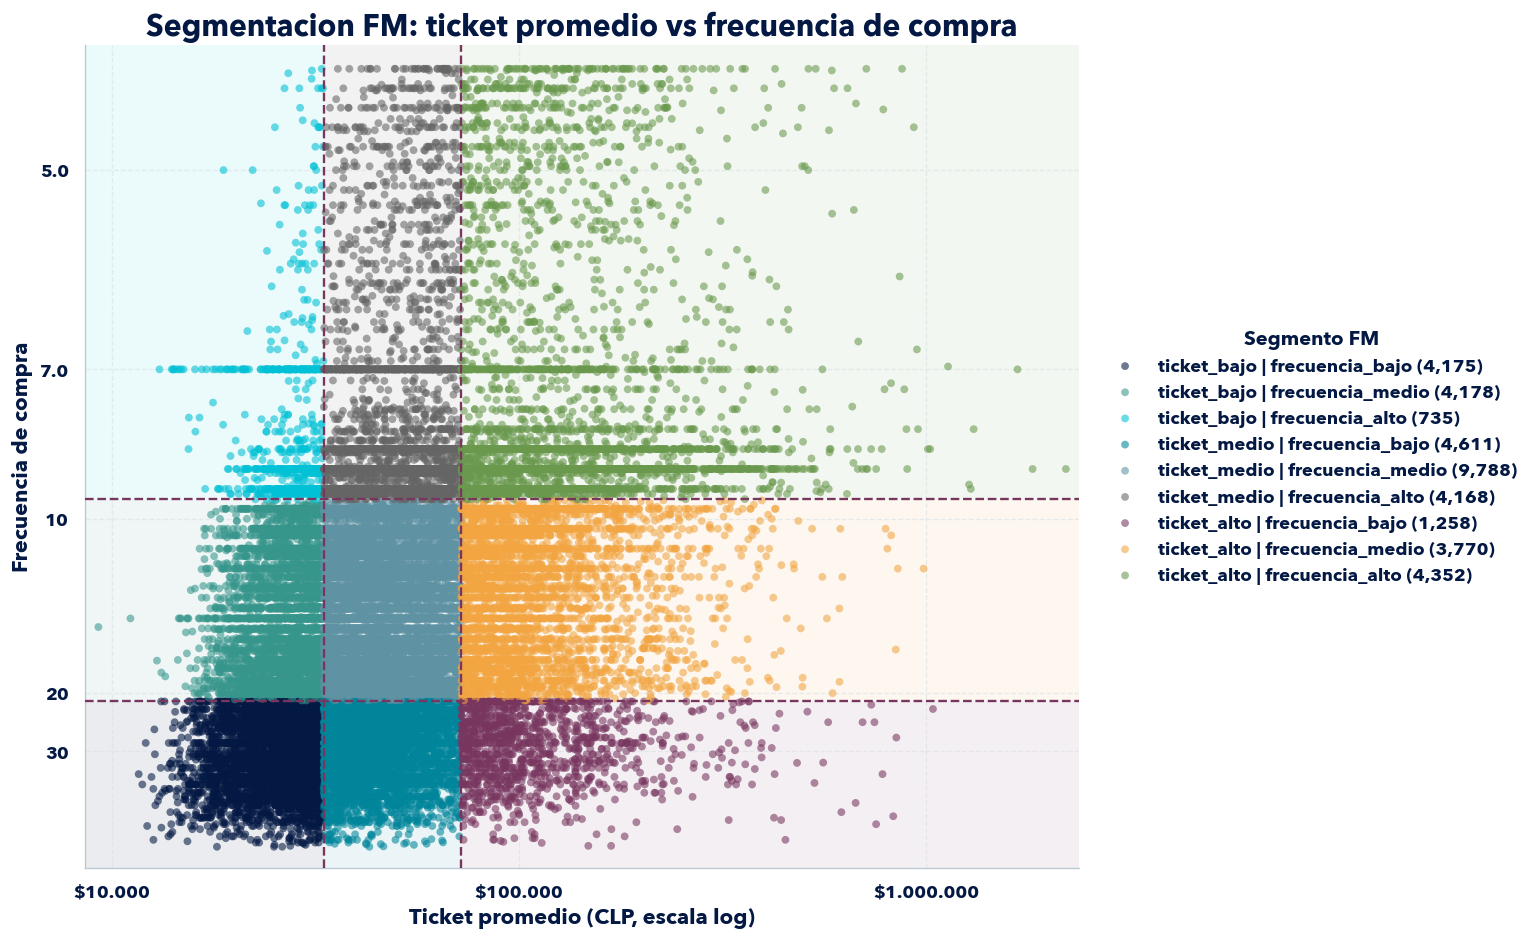

In [56]:
fig_segmentacion_fm

In [88]:
agrupaciones_segmentos_fm = {
    "VIP": ["S09"],
    "Pequeños": ["S01"],
    "Esforzado": ["S02", "S03"],
    "Fidelizados": ["S06", "S08"],
    "Neutro": ["S05"],
    "Oportunista": ["S04", "S07"],
    # "Desarrollable": ["S08"],
}


def graficar_segmentacion_fm_agrupada(
    data_clientes_plot_fm,
    umbrales_fm,
    agrupaciones_segmentos,
    *,
    ticket_col="ticket_promedio",
    frecuencia_col="frecuencia_compras",
    segmento_id_col="segmento_fm_id",
    grupo_default="Sin agrupar",
    colores_grupos=None,
    max_puntos=None,
    random_state=42,
    guardar_path=None,
):
    """Grafica la segmentacion FM juntando segmentos segun un diccionario."""
    aplicar_estilo_graficos()

    columnas_requeridas = [ticket_col, frecuencia_col, segmento_id_col]
    faltantes = [col for col in columnas_requeridas if col not in data_clientes_plot_fm.columns]
    if faltantes:
        raise ValueError(f"Faltan columnas para graficar la segmentacion FM agrupada: {faltantes}")

    if not {"q25", "q75"}.issubset(umbrales_fm.columns):
        raise ValueError("umbrales_fm debe tener columnas q25 y q75.")
    if not {ticket_col, frecuencia_col}.issubset(umbrales_fm.index):
        raise ValueError(f"umbrales_fm debe incluir indices {ticket_col!r} y {frecuencia_col!r}.")

    segmentos_repetidos = pd.Series(
        [segmento for segmentos in agrupaciones_segmentos.values() for segmento in segmentos]
    )
    if segmentos_repetidos.duplicated().any():
        repetidos = segmentos_repetidos[segmentos_repetidos.duplicated()].unique().tolist()
        raise ValueError(f"Hay segmentos repetidos en las agrupaciones: {repetidos}")

    mapa_segmento_grupo = {
        segmento: grupo
        for grupo, segmentos in agrupaciones_segmentos.items()
        for segmento in segmentos
    }

    plot_fm = _preparar_plot_fm(
        data_clientes_plot_fm,
        ticket_col=ticket_col,
        frecuencia_col=frecuencia_col,
        contexto="grafico agrupado",
    )
    plot_fm["grupo_fm"] = plot_fm[segmento_id_col].map(mapa_segmento_grupo).fillna(grupo_default)

    segmentos_sin_grupo = sorted(set(plot_fm[segmento_id_col].dropna()) - set(mapa_segmento_grupo))
    if segmentos_sin_grupo:
        print(f"Segmentos sin grupo explicito: {segmentos_sin_grupo}. Se muestran como '{grupo_default}'.")

    if max_puntos is not None and len(plot_fm) > max_puntos:
        plot_fm = plot_fm.sample(max_puntos, random_state=random_state).copy()
        print(
            f"Mostrando una muestra de {max_puntos:,} clientes sin outlier superior de frecuencia "
            f"sobre {len(data_clientes_plot_fm):,}."
        )

    colores_default = {
        "VIP": COLOR_DESTACADO,
        "Pequeños": COLORES_SUMMA["gris"],
        "Fidelizados": COLORES_SUMMA["azul_marino"],
        "Neutro": COLORES_SUMMA["azul_gris"],
        "Oportunista": COLORES_SUMMA["verde_agua"],
        "Esforzado": COLORES_SUMMA["petroleo"],
        "Desarrollable": COLORES_SUMMA["celeste"],
        grupo_default: COLOR_BORDE if "COLOR_BORDE" in globals() else "#B8C9D2",
    }
    if colores_grupos is not None:
        colores_default.update(colores_grupos)

    grupos_ordenados = list(agrupaciones_segmentos.keys())
    if grupo_default in set(plot_fm["grupo_fm"]) and grupo_default not in grupos_ordenados:
        grupos_ordenados.append(grupo_default)

    ticket_q25 = umbrales_fm.loc[ticket_col, "q25"]
    ticket_q75 = umbrales_fm.loc[ticket_col, "q75"]
    frecuencia_q25 = umbrales_fm.loc[frecuencia_col, "q25"]
    frecuencia_q75 = umbrales_fm.loc[frecuencia_col, "q75"]

    x_min = plot_fm[ticket_col].min()
    x_max = plot_fm[ticket_col].max()
    y_min = plot_fm[frecuencia_col].min()
    y_max = plot_fm[frecuencia_col].max()
    x_pad_factor = 1.08
    y_pad = (y_max - y_min) * 0.03 if y_max > y_min else max(abs(y_max) * 0.03, 0.001)
    rango_x = [max(x_min / x_pad_factor, 1e-9), x_max * x_pad_factor]
    rango_y = [max(0, y_min - y_pad), y_max + y_pad]
    x_cortes = [rango_x[0], ticket_q25, ticket_q75, rango_x[1]]
    y_cortes = [rango_y[0], frecuencia_q25, frecuencia_q75, rango_y[1]]

    niveles_ticket = ["bajo", "medio", "alto"]
    frecuencia_por_eje = ["bajo", "medio", "alto"]
    segmento_por_nivel = {
        ("bajo", "bajo"): "S01",
        ("bajo", "medio"): "S02",
        ("bajo", "alto"): "S03",
        ("medio", "bajo"): "S04",
        ("medio", "medio"): "S05",
        ("medio", "alto"): "S06",
        ("alto", "bajo"): "S07",
        ("alto", "medio"): "S08",
        ("alto", "alto"): "S09",
    }

    fig, ax = plt.subplots(figsize=(9, 8))

    for ticket_idx, ticket_nivel in enumerate(niveles_ticket):
        for frecuencia_idx, frecuencia_nivel in enumerate(frecuencia_por_eje):
            segmento_id = segmento_por_nivel[(ticket_nivel, frecuencia_nivel)]
            grupo = mapa_segmento_grupo.get(segmento_id, grupo_default)
            rect = plt.Rectangle(
                (x_cortes[ticket_idx], y_cortes[frecuencia_idx]),
                x_cortes[ticket_idx + 1] - x_cortes[ticket_idx],
                y_cortes[frecuencia_idx + 1] - y_cortes[frecuencia_idx],
                facecolor=colores_default.get(grupo, COLORES_SUMMA["gris"]),
                alpha=0.08,
                edgecolor="none",
                zorder=0,
            )
            ax.add_patch(rect)

    for grupo in grupos_ordenados:
        subset = plot_fm[plot_fm["grupo_fm"] == grupo]
        if subset.empty:
            continue
        ax.scatter(
            subset[ticket_col],
            subset[frecuencia_col],
            s=24,
            alpha=0.62,
            color=colores_default.get(grupo, COLORES_SUMMA["gris"]),
            edgecolors="none",
            label=f"{grupo} ({len(subset):,})",
            zorder=2,
        )

    for corte in [ticket_q25, ticket_q75]:
        ax.axvline(corte, color=COLOR_DESTACADO, linestyle="--", linewidth=1.4, zorder=3)
    for corte in [frecuencia_q25, frecuencia_q75]:
        ax.axhline(corte, color=COLOR_DESTACADO, linestyle="--", linewidth=1.4, zorder=3)

    ax.set_xscale("log")
    ax.set_xlim(rango_x)
    ax.set_ylim(rango_y)
    # ax.set_title("Segmentacion FM agrupada")
    # ax.set_xlabel("Ticket promedio (CLP, escala log)")
    # ax.set_ylabel("Frecuencia de compra")
    ax.xaxis.set_major_formatter(FuncFormatter(lambda valor, _: f"${valor:,.0f}".replace(",", ".")))
    _configurar_ticks_y_frecuencia(ax, rango_y)
    ax.yaxis.set_major_formatter(FuncFormatter(_formatear_frecuencia_como_dias))

    # ax.text(ticket_q25, rango_y[1], " q25 ticket", color=COLOR_DESTACADO, va="top", ha="left", fontsize=10)
    # ax.text(ticket_q75, rango_y[1], " q75 ticket", color=COLOR_DESTACADO, va="top", ha="left", fontsize=10)
    # ax.text(rango_x[1], frecuencia_q25, "q25 frecuencia ", color=COLOR_DESTACADO, va="bottom", ha="right", fontsize=10)
    # ax.text(rango_x[1], frecuencia_q75, "q75 frecuencia ", color=COLOR_DESTACADO, va="bottom", ha="right", fontsize=10)

    # ax.legend(title="Grupo FM", loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
    fig.tight_layout()

    if guardar_path is not None:
        fig.savefig(guardar_path, bbox_inches="tight")

    return fig, ax, plot_fm


resumen_agrupaciones_fm = (
    data_clientes_fm.assign(
        grupo_fm=lambda df: df["segmento_fm_id"].map(
            {
                segmento: grupo
                for grupo, segmentos in agrupaciones_segmentos_fm.items()
                for segmento in segmentos
            }
        ).fillna("Sin agrupar")
    )
    .groupby("grupo_fm", as_index=False)
    .agg(
        clientes=("Cod Cliente", "count"),
        ticket_promedio_mediana=("ticket_promedio", "median"),
        dias_entre_compras_mediana=("dias_entre_compras", "median"),
        frecuencia_compras_mediana=("frecuencia_compras", "median"),
    )
    .sort_values("clientes", ascending=False)
    .reset_index(drop=True)
)

display(resumen_agrupaciones_fm)

fig_segmentacion_fm_agrupada, ax_segmentacion_fm_agrupada, data_clientes_plot_fm_agrupada = (
    graficar_segmentacion_fm_agrupada(
        data_clientes_plot_fm,
        umbrales_fm,
        agrupaciones_segmentos_fm,
    )
)


,grupo_fm,clientes,ticket_promedio_mediana,dias_entre_compras_mediana,frecuencia_compras_mediana
0,Neutro,9788,46023.854167,12.923077,0.077381
1,Fidelizados,8004,69748.498452,9.333333,0.107143
2,Oportunista,6434,48079.785714,28.000000,0.035714
3,Esforzado,4928,27798.968750,13.363636,0.074830
4,Pequeños,4592,26149.500000,30.800000,0.032468
5,VIP,4560,111938.666086,8.631579,0.115854


Clientes sin ticket/frecuencia graficable excluidos del grafico agrupado: 982.


In [89]:
umbrales_fm

,q25,q75
ticket_promedio,33173.500000,72197.902439
frecuencia_compras,0.047619,0.105556


In [90]:
1/0.105556	

9.473644321497593

In [91]:
1/0.047619	


21.000021000021

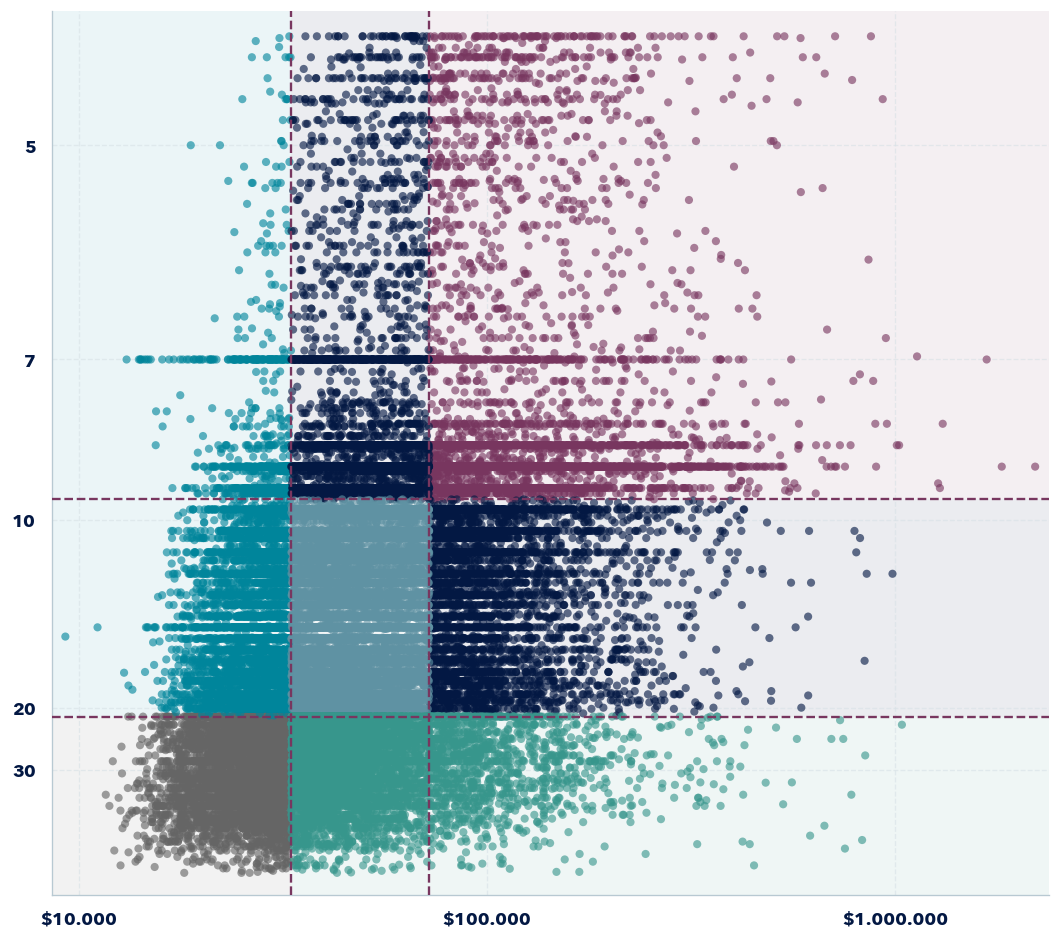

In [92]:
fig_segmentacion_fm_agrupada

In [93]:
margenes_cliente = costos.groupby("Cod Cliente").agg({
    "Kilo Real": "sum",
    "Monto Real": "sum",
    "Margen Directo": "sum",
    "Margen 1": "sum",
    "Margen 2": "sum",
    "EBITDA": "sum"
}).rename(columns={
    "Kilo Real": "Kilos",
    "Monto Real": "Ingresos"
}).reset_index()
margenes_cliente.head()

NameError: name 'costos' is not defined

In [45]:
data_clientes_fm.head()

,Cod Cliente,venta_total_clp,n_facturas,ticket_promedio,ticket_desv_std,dias_entre_compras,recencia,skus_distintos,share_marca_LA PREFERIDA,share_marca_SAN JORGE,...,Distrito,Comuna,Canal,SubCanal,TipoNeg,frecuencia_compras,ticket_promedio_nivel,frecuencia_nivel,segmento_fm_id,segmento_fm_desc
0,1199536,585105,22,26595.681818,11318.573805,17.500000,7,13,0.103703,0.582817,...,TALCA,LINARES,COBERTURA,COBERTURA,AL,0.057143,bajo,medio,S02,ticket_bajo | frecuencia_medio
1,1178409,2097246,19,110381.368421,53531.642320,10.937500,6,23,0.276496,0.447796,...,VIÑA INTERIOR,QUILLOTA,COBERTURA,COBERTURA,AL,0.091429,alto,medio,S08,ticket_alto | frecuencia_medio
2,1096778,6157719,22,279896.318182,89942.106524,8.333333,7,24,0.696572,0.118202,...,SANTIAGO CENTRO COSTA,SAN ANTONIO,COBERTURA,VOLUMEN COBERTURA,AL,0.120000,alto,alto,S09,ticket_alto | frecuencia_alto
3,1151218,1750131,20,87506.550000,55561.389468,10.937500,7,35,0.254685,0.171271,...,SANTIAGO CENTRO COSTA,SAN ANTONIO,COBERTURA,COBERTURA,AL,0.091429,alto,medio,S08,ticket_alto | frecuencia_medio
4,1000127,271058,9,30117.555556,2845.885500,21.875000,7,5,0.014303,0.057224,...,SAN FELIPE,LOS ANDES,COBERTURA,COBERTURA,AL,0.045714,bajo,bajo,S01,ticket_bajo | frecuencia_bajo


In [46]:
data_clientes_fm.columns

Index(['Cod Cliente', 'venta_total_clp', 'n_facturas', 'ticket_promedio',
       'ticket_desv_std', 'dias_entre_compras', 'recencia', 'skus_distintos',
       'share_marca_LA PREFERIDA', 'share_marca_SAN JORGE',
       'share_marca_WINTER', 'share_marca_Los Nogales',
       'share_familia_LACTEOS', 'share_familia_MORTADELAS',
       'share_familia_VIENESAS', 'share_familia_PATE', 'share_familia_QUESOS',
       'share_familia_HORTALIZAS', 'share_familia_JAMON G1',
       'share_familia_SNACKS', 'share_familia_SALAMES',
       'share_familia_JAMON G2', 'share_familia_ARROLLADOS',
       'share_familia_HAMBURGUESAS', 'share_familia_OTROS COMERCIALIZADORA',
       'share_familia_CARNES', 'share_familia_TIPICOS',
       'share_familia_FIAMBRES', 'share_familia_PARRILLEROS',
       'share_familia_TOCINOS', 'share_familia_EMPANIZADOS',
       'share_familia_SECOS', 'share_empaque_ENVASADO', 'share_empaque_GRANEL',
       'hhi_marcas', 'hhi_familias', 'Zona', 'Distrito', 'Comuna', 'Canal',
   

In [94]:
agrupaciones_segmentos_fm = {
    "VIP": ["S09"],
    "Pequeños": ["S01"],
    "Esforzado": ["S02", "S03"],
    "Fidelizados": ["S06", "S08"],
    "Neutro": ["S05"],
    #"Desarrollable": ["S08"],
    "Oportunista": ["S04", "S07"],
}
mapeo_seg_agrupado = {
    "S01": "Pequeños",
    "S02": "Esforzado",
    "S03": "Esforzado",
    "S04": "Oportunista",
    "S05": "Neutro",
    "S06": "Fidelizados",
    "S07": "Oportunista",
    # "S08": "Desarrollable",
    "S08": "Fidelizados",
    "S09": "VIP",
}
data_clientes_fm["segmento_fm_agrupado"] = data_clientes_fm["segmento_fm_id"].map(mapeo_seg_agrupado)

data_clientes_fm[[
    "Cod Cliente",
    "ticket_promedio",
    "ticket_promedio_nivel",
    "dias_entre_compras",
    "frecuencia_compras",
    "frecuencia_nivel",
    'segmento_fm_id',
    'segmento_fm_desc',
    "segmento_fm_agrupado"
]].to_csv("segmentacion_fm_vs_desarrollables.csv", index=False)

In [51]:
ventas[
    ventas["Cod Cliente"] == 1242595
]["Fecha Factura"].unique()

<DatetimeArray>
['2026-03-31 00:00:00']
Length: 1, dtype: datetime64[us]